In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']

BASE_PATH = r'C:\Users\ans\Desktop\CS-604 FYP\Final Year Project'
FILE_PATH = os.path.join(BASE_PATH, 'reviews_Baby_5.csv')

In [21]:
try:
    data = pd.read_csv(FILE_PATH)
    print(data.head(10))
    data = data[['reviewText', 'overall']].dropna()
    
    # Neutral reviews (3) removing
    data = data[data['overall'] != 3]
    data['churn'] = data['overall'].apply(lambda x: 1 if x <= 2 else 0)
    
    # 1:1 ratio for authentic research results
    minority_size = len(data[data['churn'] == 1])
    stay_sample = data[data['churn'] == 0].sample(n=minority_size, random_state=42)
    churn_sample = data[data['churn'] == 1]
    
    df_final = pd.concat([stay_sample, churn_sample]).sample(frac=1, random_state=42)
    
    print(f"Data ready for analysis. Total Rows: {len(df_final)}")
    print(f"Churn Ratio:\n{df_final['churn'].value_counts(normalize=True)}")
except Exception as e:
    print(f"File reading error: {e}")

                                          reviewText  overall  \
0  Perfect for new parents. We were able to keep ...      5.0   
1  This book is such a life saver.  It has been s...      5.0   
2  Helps me know exactly how my babies day has go...      5.0   
3  I bought this a few times for my older son and...      5.0   
4  I wanted an alternative to printing out daily ...      4.0   
5  This is great for basics, but I wish the space...      4.0   
6  My 3 month old son spend half of his days with...      5.0   
7  This book is perfect!  I'm a first time new mo...      5.0   
8  I wanted to love this, but it was pretty expen...      3.0   
9  The Baby Tracker brand books are the absolute ...      5.0   

                                             summary  
0                                            Awesine  
1            Should be required for all new parents!  
2                          Grandmother watching baby  
3                                       repeat buyer  
4        

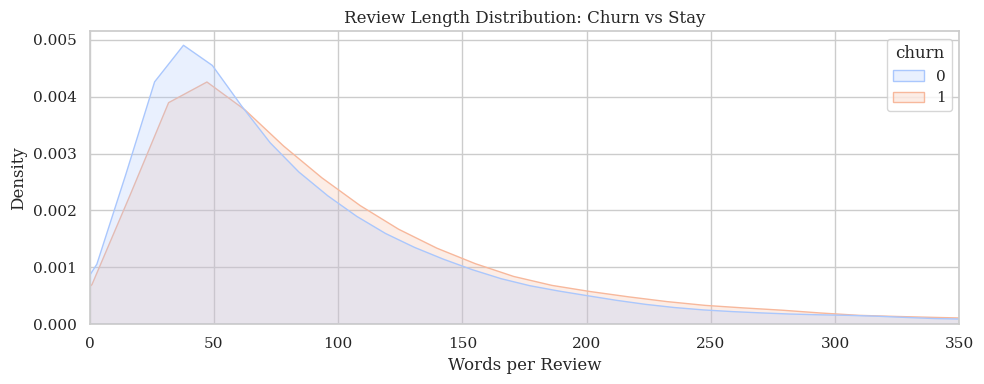

In [22]:
df_final['word_count'] = df_final['reviewText'].str.split().str.len()

plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_final, x='word_count', hue='churn', fill=True, palette='coolwarm')
plt.title('Review Length Distribution: Churn vs Stay')
plt.xlabel('Words per Review')
plt.xlim(0, 350)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.feature_extraction import text

domain_stop_words = text.ENGLISH_STOP_WORDS.union(['baby', 'product', 'amazon', 'item', 'bought', 'got', 'really'])

vectorizer = TfidfVectorizer(
    max_features=25000, 
    stop_words=list(domain_stop_words),
    ngram_range=(1, 3),
    sublinear_tf=True
)

features = vectorizer.fit_transform(df_final['reviewText'])
labels = df_final['churn']

x_train, x_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Refined Feature engineering complete. Dimension: {features.shape}")

Refined Feature engineering complete. Dimension: (34002, 25000)


In [24]:
from sklearn import set_config
from sklearn.naive_bayes import MultinomialNB

set_config(display='diagram')

# Base Learners: Research standard parameters
# C=0.8 aur learning_rate=0.1 
svc_logic = CalibratedClassifierCV(LinearSVC(C=0.8, dual=False, max_iter=2500), method='sigmoid')
xgb_logic = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='logloss')
nb_logic = MultinomialNB(alpha=0.1)

# Stacking Framework
# Meta-learner (LogisticRegression) 
stacking_architecture = StackingClassifier(
    estimators=[
        ('SVC_Linear', svc_logic),
        ('XGBoost_Trees', xgb_logic),
        ('Naive_Bayes', nb_logic)
    ],
    final_estimator=LogisticRegression(C=1.0),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Training
stacking_architecture.fit(x_train, y_train)

# diagram display 
stacking_architecture

StackingClassifier(cv=5,
                   estimators=[('SVC_Linear',
                                CalibratedClassifierCV(estimator=LinearSVC(C=0.8,
                                                                           dual=False,
                                                                           max_iter=2500))),
                               ('XGBoost_Trees',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logl...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=4,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('Naive_Bayes', MultinomialNB(alpha=0.1))],
                   final_estimator=LogisticRegression(), n_jobs=-1,
                   stack_method='predict_proba')

In [25]:
from sklearn.model_selection import cross_val_score

print("Validating Model Stability using 5-Fold Cross-Validation...")

cv_scores = cross_val_score(stacking_architecture, x_train, y_train, cv=5, n_jobs=-1)

print(f"\n--- Cross-Validation Results ---")
print(f"Individual Fold Accuracies: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Validating Model Stability using 5-Fold Cross-Validation...

--- Cross-Validation Results ---
Individual Fold Accuracies: [0.88513141 0.87444853 0.87794118 0.88069853 0.87830882]
Mean Accuracy: 0.8793
Standard Deviation: 0.0035



--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      3401
           1       0.88      0.89      0.89      3400

    accuracy                           0.89      6801
   macro avg       0.89      0.89      0.89      6801
weighted avg       0.89      0.89      0.89      6801



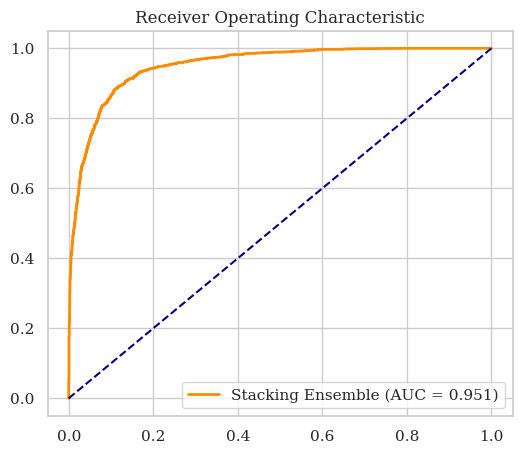

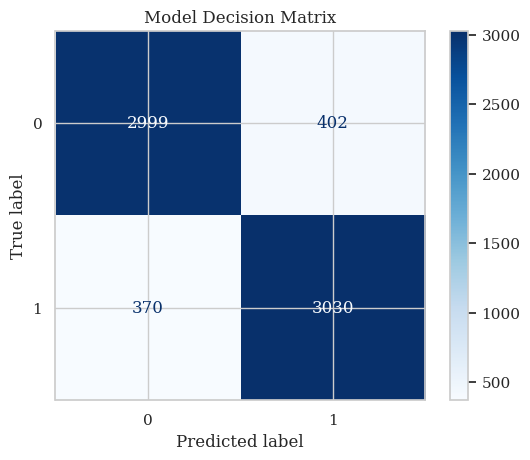

In [26]:
y_pred = stacking_architecture.predict(x_test)
y_prob = stacking_architecture.predict_proba(x_test)[:, 1]

print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred))

# ROC-AUC Curve Visualization
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Stacking Ensemble (AUC = {auc(fpr, tpr):.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(stacking_architecture, x_test, y_test, cmap='Blues')
plt.title('Model Decision Matrix')
plt.show()

In [27]:
# Model Comparison (Individual vs Stacking)
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Train individual models again (or reuse if stored)
svc_logic.fit(x_train, y_train)
xgb_logic.fit(x_train, y_train)
nb_logic.fit(x_train, y_train)

models_dict = {
    'Linear SVC': svc_logic,
    'XGBoost': xgb_logic,
    'Naive Bayes': nb_logic,
    'Proposed Stacking': stacking_architecture
}

comp_results = []
for name, mdl in models_dict.items():
    y_pred_mdl = mdl.predict(x_test)
    comp_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_mdl),
        'Precision': precision_score(y_test, y_pred_mdl, average='weighted'),
        'Recall': recall_score(y_test, y_pred_mdl, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred_mdl, average='weighted')
    })

df_comp = pd.DataFrame(comp_results)
print("\n=== MODEL COMPARISON ===\n")
print(df_comp.to_string(index=False))


=== MODEL COMPARISON ===

            Model  Accuracy  Precision   Recall  F1-Score
       Linear SVC  0.879577   0.879597 0.879577  0.879575
          XGBoost  0.796648   0.799628 0.796648  0.796143
      Naive Bayes  0.853992   0.854331 0.853992  0.853958
Proposed Stacking  0.886487   0.886522 0.886487  0.886485


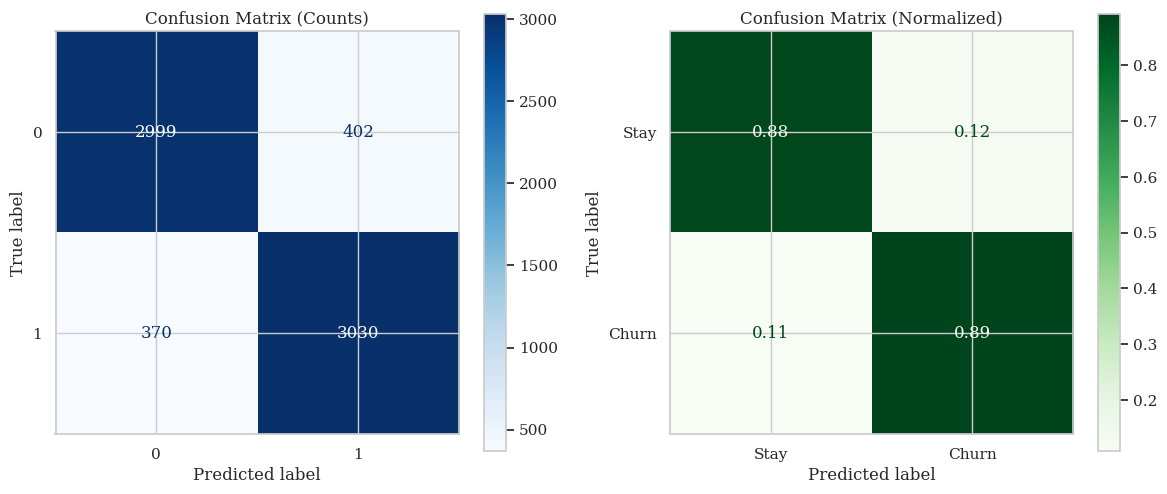

In [28]:
# Normalized Confusion Matrix for better readability
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
ConfusionMatrixDisplay.from_estimator(stacking_architecture, x_test, y_test, 
                                       cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized (percentages)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Stay', 'Churn'])
disp.plot(ax=axes[1], cmap='Greens', values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

In [29]:
# Cross-validation for each model
print("\n=== CROSS-VALIDATION STABILITY (5-Fold) ===\n")
for name, mdl in models_dict.items():
    scores = cross_val_score(mdl, x_train, y_train, cv=5, n_jobs=-1)
    print(f"{name:20} | Mean Acc: {scores.mean():.4f} (+/- {scores.std():.4f})")


=== CROSS-VALIDATION STABILITY (5-Fold) ===

Linear SVC           | Mean Acc: 0.8738 (+/- 0.0041)
XGBoost              | Mean Acc: 0.7966 (+/- 0.0051)
Naive Bayes          | Mean Acc: 0.8505 (+/- 0.0051)
Proposed Stacking    | Mean Acc: 0.8793 (+/- 0.0035)


In [30]:
# Models saving
model_save_path = os.path.join(BASE_PATH, 'hybrid_model.pkl')
vectorizer_save_path = os.path.join(BASE_PATH, 'tfidf_vectorizer.pkl')

# Saving assets
joblib.dump(stacking_architecture, model_save_path)
joblib.dump(vectorizer, vectorizer_save_path)

print(f"Models Saved Successfully:")
print(f"1. Model: {model_save_path}")
print(f"2. Vectorizer: {vectorizer_save_path}")

Models Saved Successfully:
1. Model: C:\Users\ans\Desktop\CS-604 FYP\Final Year Project\hybrid_model.pkl
2. Vectorizer: C:\Users\ans\Desktop\CS-604 FYP\Final Year Project\tfidf_vectorizer.pkl
